In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

In [4]:
X, _ = make_blobs(n_samples=1000, centers=4, cluster_std= 1, random_state=42)

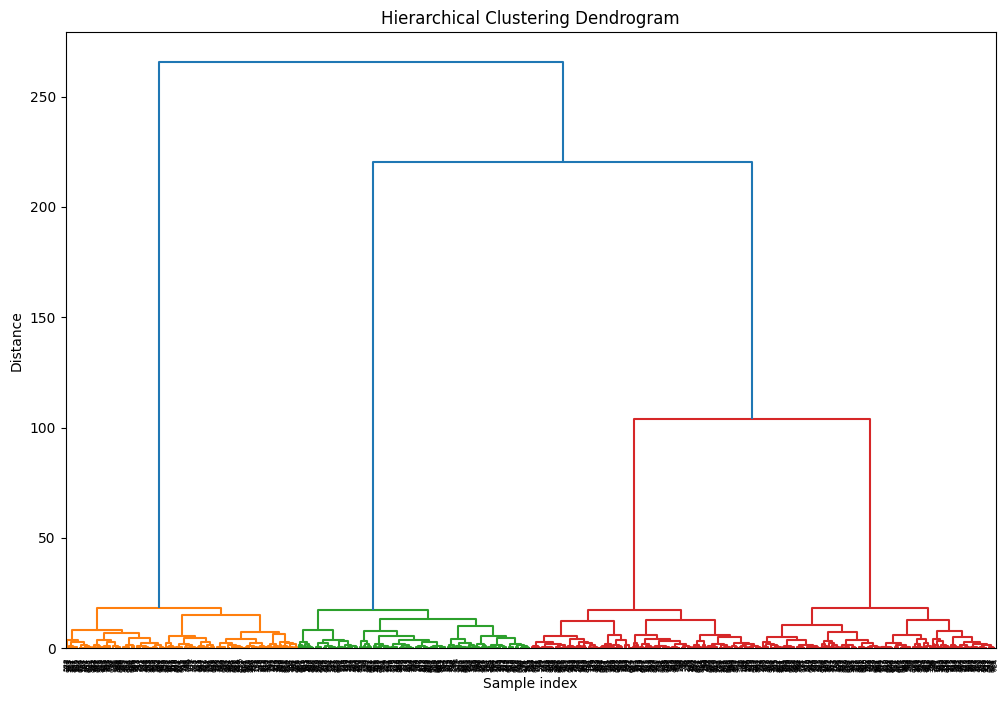

In [5]:
plt.figure(figsize=(12, 8))
Z = linkage(X, method='ward')
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

In [6]:
import ipywidgets as widgets
from ipywidgets import interact, IntSlider, Dropdown

# Generat Data
X, _ = make_blobs(n_samples=1000, centers=4, cluster_std= 1, random_state=42)

# Linkage Matrix
Z = linkage(X, method='ward')

def plot_cluster(n_clusters):
    clusters = fcluster(Z, n_clusters, criterion='maxclust')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    dendrogram(Z, ax=ax1)

    # Find the height that gives the exactly n_clusters
    # The cut height is the distance at the (n_clusters-1)th merge from the top
    cut_height = Z[-(n_clusters-1), 2] if n_clusters > 1 else Z[-1, 2]
    ax1.axhline(y=cut_height, color='r', linestyle='--', linewidth=2, label=f'Cut at {cut_height:.2f}')
    ax1.set_title(f'Hierarchical Clustering Dendrogram (n_clusters={n_clusters})')
    ax1.set_xlabel('Sample index')
    ax1.set_ylabel('Distance')
    ax1.legend()

    # Plot 2: Resulting Clusters in 2D
    scattter = ax2.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)
    ax2.set_title(f'Hierarchical Clustering Result (n_clusters={n_clusters})')
    ax2.set_xlabel('Feature 1') 
    ax2.set_ylabel('Feature 2')
    plt.colorbar(scattter, ax=ax2, label='Cluster Label')

    plt.tight_layout()
    plt.show()

    # show cluster sizes
    unique, counts = np.unique(clusters, return_counts=True)
    print(f'Cluster Sizes: {dict(zip(unique, counts))}')
    for cluster_id, count in zip(unique, counts):
        print(f'Cluster {cluster_id}: {count} samples')

# interactive widget to select number of clusters
interact(plot_cluster, n_clusters=IntSlider(min=2, max=10, step=1, value=3))

interactive(children=(IntSlider(value=3, description='n_clusters', max=10, min=2), Output()), _dom_classes=('w…

<function __main__.plot_cluster(n_clusters)>